# Análisis Exploratorio de Datos (EDA) - EnergiAI
Dataset Inicial de Consumo Energético

### 1. Configuración inicial

In [1]:
#import os
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuración de gráficos
plt.style.use('ggplot')
sns.set_palette("Set2")
%matplotlib inline

DATA_PATH = '../data/processed/dataset_inicial.csv'
#OUTPUT_IMAGES_PATH = '../images/eda/'
#os.makedirs(OUTPUT_IMAGES_PATH, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("Dataset cargado correctamente.")
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas.")
print("\nPrimeras 5 filas:")
display(df.head()) 

Dataset cargado correctamente.
Dimensiones: 2000 filas, 6 columnas.

Primeras 5 filas:


,consumo_kwh,cantidad_equipos,horas_alto_consumo,tipo_inmueble,uso_horario_pico,categoria
0,182,6,3,Casa,True,Moderado
1,515,5,12,Local,True,Ineficiente
2,940,21,13,Apartamento,True,Moderado
3,350,5,13,Casa,False,Ineficiente
4,186,19,7,Casa,True,Moderado


### 2. Estructura y tipos de datos

In [2]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   consumo_kwh         2000 non-null   int64
 1   cantidad_equipos    2000 non-null   int64
 2   horas_alto_consumo  2000 non-null   int64
 3   tipo_inmueble       2000 non-null   str  
 4   uso_horario_pico    2000 non-null   bool 
 5   categoria           2000 non-null   str  
dtypes: bool(1), int64(3), str(2)
memory usage: 80.2 KB


In [3]:
# Resumen estadístico para variables numéricas
df.describe()

,consumo_kwh,cantidad_equipos,horas_alto_consumo
count,2000.000000,2000.000000,2000.000000
mean,511.936500,11.473000,7.531000
std,256.944967,5.765491,3.441215
min,80.000000,2.000000,2.000000
25%,287.750000,6.000000,5.000000
50%,510.500000,12.000000,8.000000
75%,743.000000,16.000000,11.000000
max,949.000000,21.000000,13.000000


In [4]:
# Resumen estadístico para variables categóricas
display(df.describe(include=['object', 'bool']))

,tipo_inmueble,uso_horario_pico,categoria
count,2000,2000,2000
unique,4,2,3
top,Casa,False,Moderado
freq,1027,1125,1493


In [5]:
# Conteo de valores únicos para variables categóricas
print(df["tipo_inmueble"].value_counts(),"\n")
print(df["uso_horario_pico"].value_counts(),"\n")
print(df["categoria"].value_counts(),"\n")

tipo_inmueble
Casa           1027
Apartamento     579
Local           211
Oficina         183
Name: count, dtype: int64 

uso_horario_pico
False    1125
True      875
Name: count, dtype: int64 

categoria
Moderado       1493
Ineficiente     403
Eficiente       104
Name: count, dtype: int64 



In [6]:
# Verificación de valores nulos
print(df.isnull().sum())

consumo_kwh           0
cantidad_equipos      0
horas_alto_consumo    0
tipo_inmueble         0
uso_horario_pico      0
categoria             0
dtype: int64


### 3. Análisis exploratorio univariado

In [7]:
num_cols = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo']

for col in num_cols:
    print(f"Variable: {col}")
    print("-" * 40)
    print(f"Rango: [{df[col].min()}, {df[col].max()}]")
    print(f"Media: {df[col].mean():.2f}")
    print(f"Mediana: {df[col].median():.2f}")
    print(f"Desviación estándar: {df[col].std():.2f}")
    print(f"Coeficiente de variación: {(df[col].std()/df[col].mean())*100:.2f}%")
    print("\n")

Variable: consumo_kwh
----------------------------------------
Rango: [80, 949]
Media: 511.94
Mediana: 510.50
Desviación estándar: 256.94
Coeficiente de variación: 50.19%


Variable: cantidad_equipos
----------------------------------------
Rango: [2, 21]
Media: 11.47
Mediana: 12.00
Desviación estándar: 5.77
Coeficiente de variación: 50.25%


Variable: horas_alto_consumo
----------------------------------------
Rango: [2, 13]
Media: 7.53
Mediana: 8.00
Desviación estándar: 3.44
Coeficiente de variación: 45.69%




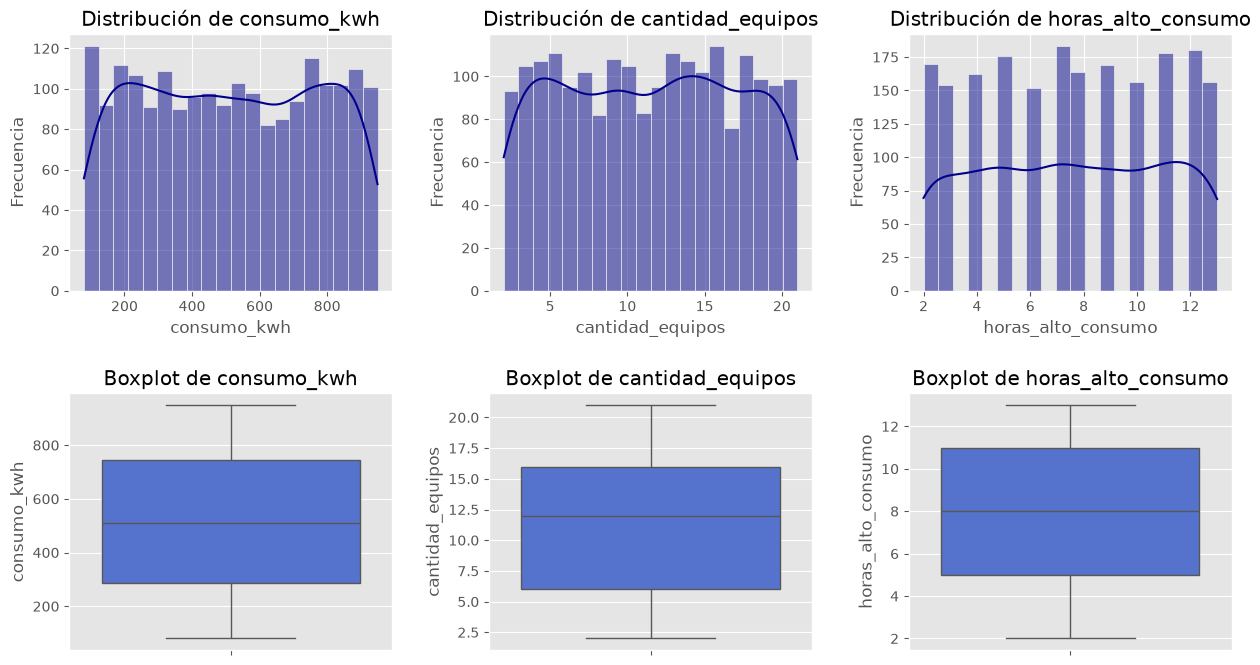

In [8]:
# Gráficos para variables numéricas
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Histograma + KDE
    sns.histplot(df[col], kde=True, ax=axes[i], color='darkblue', bins=20)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    
    # Boxplot
    sns.boxplot(y=df[col], ax=axes[i+3], color='royalblue')
    axes[i+3].set_title(f'Boxplot de {col}')
    axes[i+3].set_ylabel(col)

#plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.3)
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/univariado_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Variables categóricas
cat_cols = ['tipo_inmueble', 'uso_horario_pico', 'categoria']

for col in cat_cols:
    print(f"Variable: {col}")
    print("-" * 40)
    print(df[col].value_counts())
    print(f"\nProporciones:\n{df[col].value_counts(normalize=True).round(3)}")
    print("\n")

Variable: tipo_inmueble
----------------------------------------
tipo_inmueble
Casa           1027
Apartamento     579
Local           211
Oficina         183
Name: count, dtype: int64

Proporciones:
tipo_inmueble
Casa           0.514
Apartamento    0.290
Local          0.106
Oficina        0.092
Name: proportion, dtype: float64


Variable: uso_horario_pico
----------------------------------------
uso_horario_pico
False    1125
True      875
Name: count, dtype: int64

Proporciones:
uso_horario_pico
False    0.562
True     0.438
Name: proportion, dtype: float64


Variable: categoria
----------------------------------------
categoria
Moderado       1493
Ineficiente     403
Eficiente       104
Name: count, dtype: int64

Proporciones:
categoria
Moderado       0.746
Ineficiente    0.202
Eficiente      0.052
Name: proportion, dtype: float64




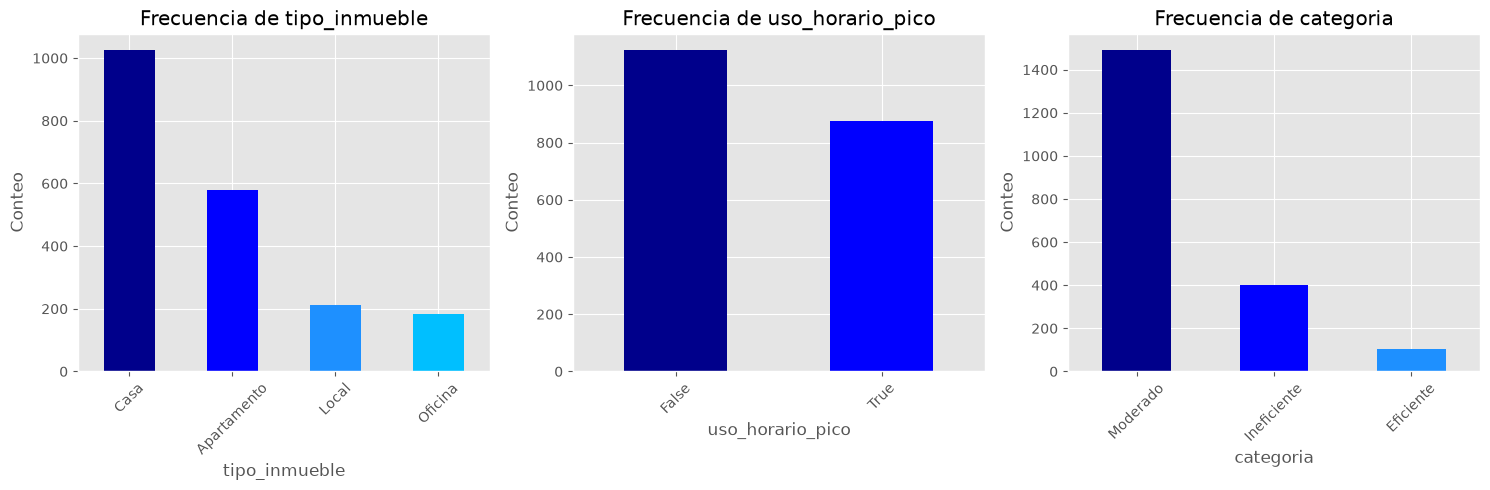

In [10]:
# Gráficos para variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color=['darkblue', 'blue', 'dodgerblue', 'deepskyblue'])
    axes[i].set_title(f'Frecuencia de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Conteo')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/univariado_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Variable objetivo: categoría
print("Distribución de la variable objetivo:")
print("-" * 40)
print(df['categoria'].value_counts())
print(f"\nProporciones:\n{df['categoria'].value_counts(normalize=True).round(3)}")

Distribución de la variable objetivo:
----------------------------------------
categoria
Moderado       1493
Ineficiente     403
Eficiente       104
Name: count, dtype: int64

Proporciones:
categoria
Moderado       0.746
Ineficiente    0.202
Eficiente      0.052
Name: proportion, dtype: float64


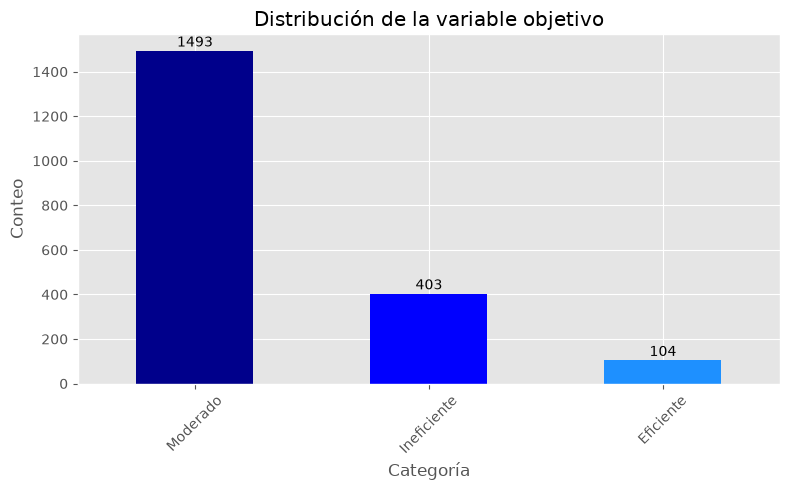

In [12]:
# Gráfico de barras con etiquetas
fig, ax = plt.subplots(figsize=(8, 5))
df['categoria'].value_counts().plot(kind='bar', ax=ax, color=['darkblue', 'blue', 'dodgerblue'])
ax.set_title('Distribución de la variable objetivo')
ax.set_xlabel('Categoría')
ax.set_ylabel('Conteo')
ax.tick_params(axis='x', rotation=45)

for i, v in enumerate(df['categoria'].value_counts()):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/distribucion_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Detección de outliers usando IQR
print("Valores atípicos por variable numérica:")
print("-" * 40)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} valores atípicos ({len(outliers)/len(df)*100:.2f}%)")

Valores atípicos por variable numérica:
----------------------------------------
consumo_kwh: 0 valores atípicos (0.00%)
cantidad_equipos: 0 valores atípicos (0.00%)
horas_alto_consumo: 0 valores atípicos (0.00%)


### 4. Análisis bivariado y multivariado

Matriz de correlación entre variables numéricas:
--------------------------------------------------


,consumo_kwh,cantidad_equipos,horas_alto_consumo
consumo_kwh,1.000000,0.001534,0.043564
cantidad_equipos,0.001534,1.000000,-0.016322
horas_alto_consumo,0.043564,-0.016322,1.000000


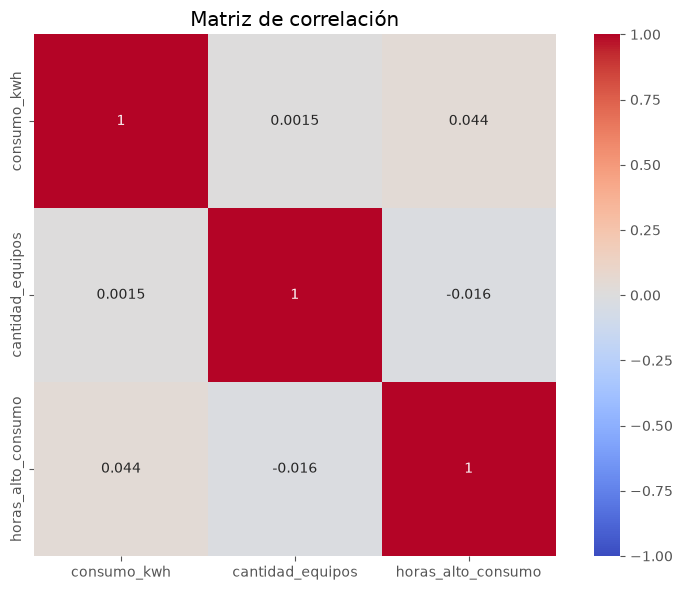

In [14]:
# Matriz de correlación
num_cols = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo']
corr = df[num_cols].corr()

print("Matriz de correlación entre variables numéricas:")
print("-" * 50)
display(corr)

# Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriz de correlación')
plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

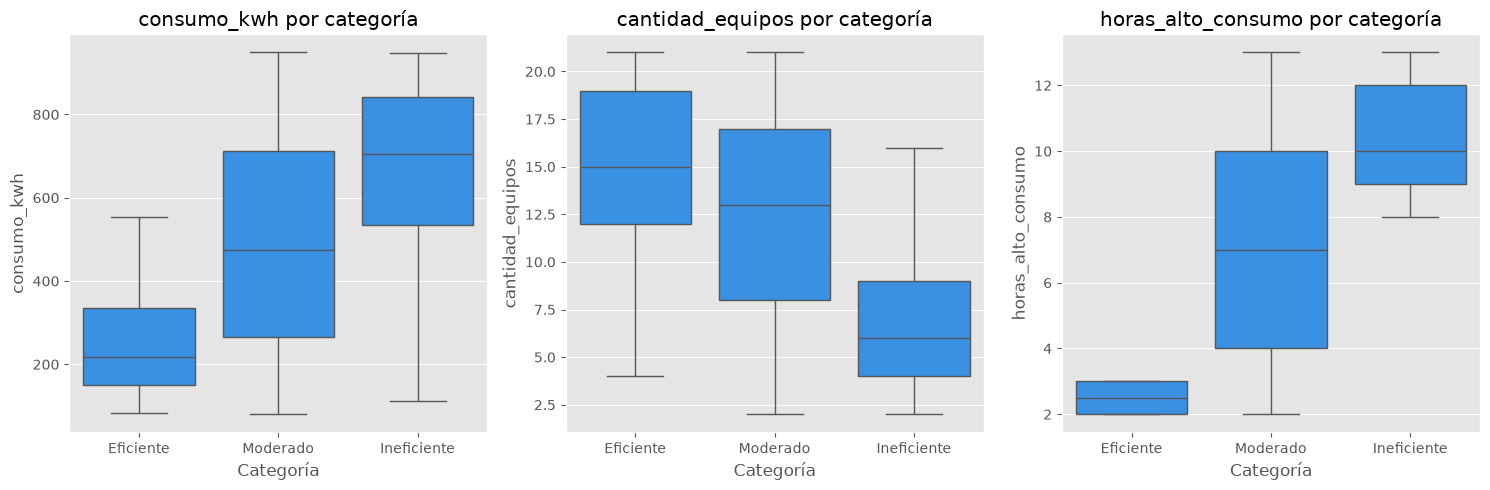

In [15]:
# Boxplots de variables numéricas por categoría
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='categoria', y=col, ax=axes[i], order=['Eficiente', 'Moderado', 'Ineficiente'], color='dodgerblue')
    axes[i].set_title(f'{col} por categoría')
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylabel(col)

plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/boxplot_numericas_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

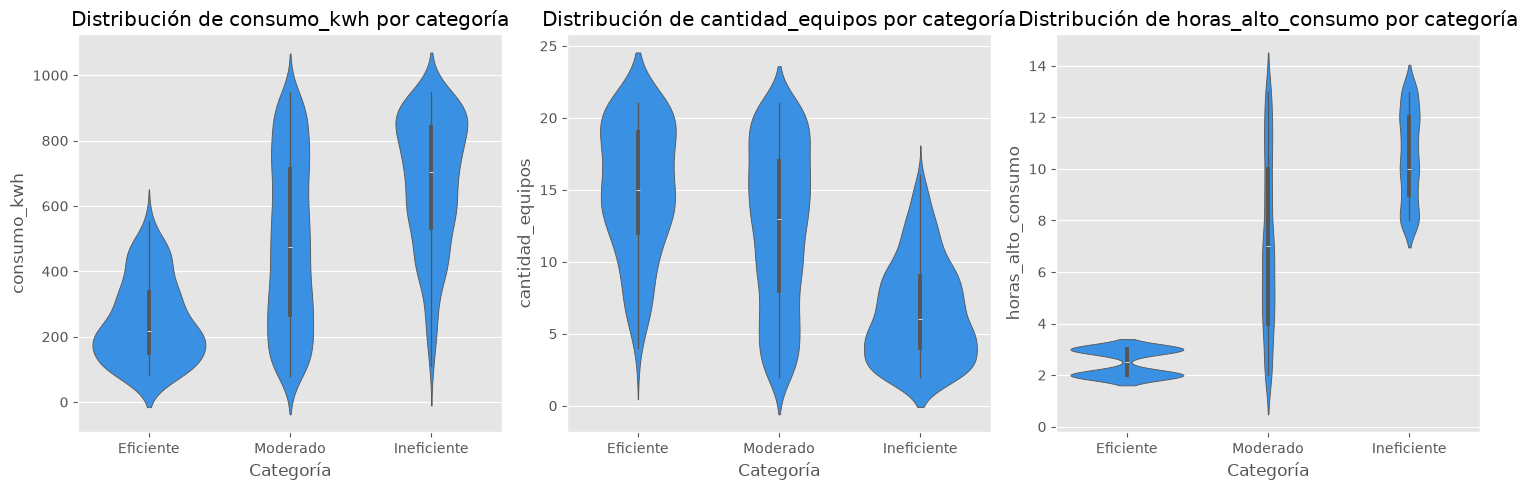

In [16]:
# Violin plots para ver la distribución
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    sns.violinplot(data=df, x='categoria', y=col, ax=axes[i], order=['Eficiente', 'Moderado', 'Ineficiente'], color='dodgerblue')
    axes[i].set_title(f'Distribución de {col} por categoría')
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylabel(col)

plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/violin_numericas_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

Tabla de contingencia: tipo_inmueble vs categoria
--------------------------------------------------


categoria,Eficiente,Ineficiente,Moderado,All
tipo_inmueble,,,,
Apartamento,38,123,418,579
Casa,44,209,774,1027
Local,14,39,158,211
Oficina,8,32,143,183
All,104,403,1493,2000



Proporciones por categoría:


categoria,Eficiente,Ineficiente,Moderado
tipo_inmueble,,,
Apartamento,0.365385,0.305211,0.279973
Casa,0.423077,0.518610,0.518419
Local,0.134615,0.096774,0.105827
Oficina,0.076923,0.079404,0.095780




Tabla de contingencia: uso_horario_pico vs categoria
--------------------------------------------------


categoria,Eficiente,Ineficiente,Moderado,All
uso_horario_pico,,,,
False,56,223,846,1125
True,48,180,647,875
All,104,403,1493,2000



Proporciones por categoría:


categoria,Eficiente,Ineficiente,Moderado
uso_horario_pico,,,
False,0.538462,0.55335,0.566644
True,0.461538,0.44665,0.433356


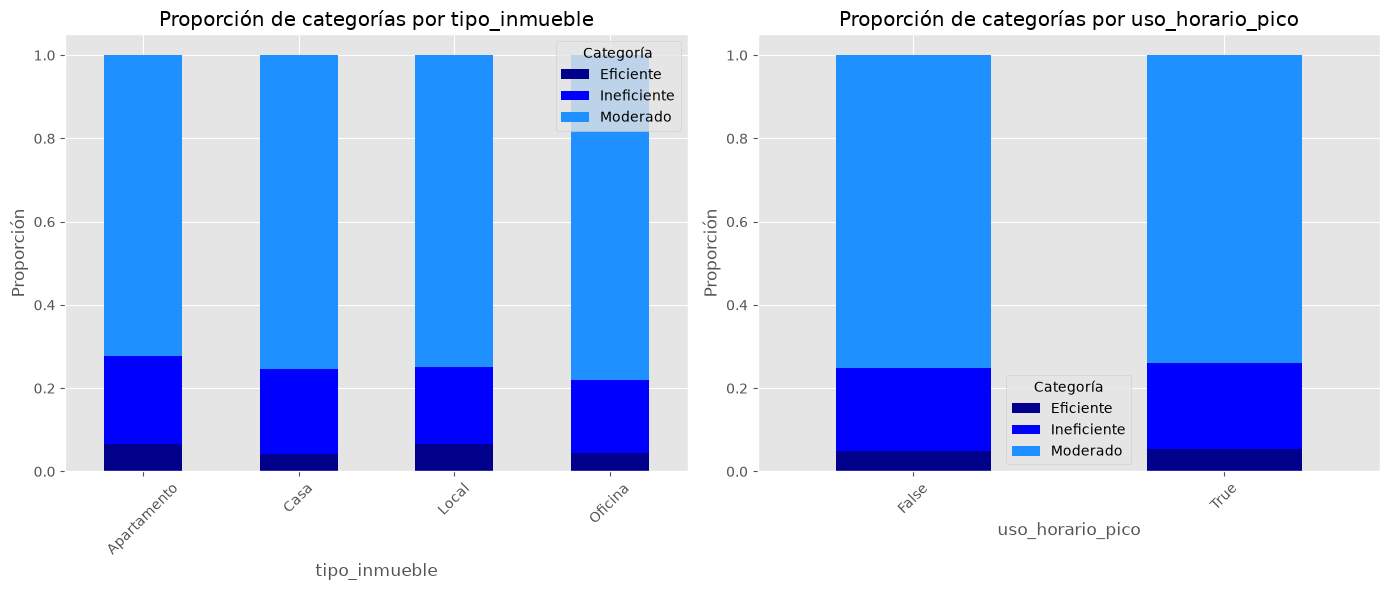

In [17]:
# Tablas de contingencia y gráficos de barras apiladas
cat_cols = ['tipo_inmueble', 'uso_horario_pico']

for col in cat_cols:
    print(f"Tabla de contingencia: {col} vs categoria")
    print("-" * 50)
    contingency = pd.crosstab(df[col], df['categoria'], margins=True)
    display(contingency)
    
    # Proporciones por categoría
    prop = pd.crosstab(df[col], df['categoria'], normalize='columns')
    print("\nProporciones por categoría:")
    display(prop)
    print("\n")

# Gráficos de barras apiladas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, col in enumerate(cat_cols):
    # Datos para el gráfico
    cross = pd.crosstab(df[col], df['categoria'], normalize='index')
    cross.plot(kind='bar', stacked=True, ax=axes[i], 
               color=['darkblue', 'blue', 'dodgerblue'])
    axes[i].set_title(f'Proporción de categorías por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proporción')
    axes[i].legend(title='Categoría')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/barras_apiladas_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

Distribución del ratio (consumo/equipos) por categoría:
------------------------------------------------------------
              count        mean        std        min        25%        50%  \
categoria                                                                     
Eficiente     104.0   16.689246   6.426255   5.250000  11.930556  16.948413   
Ineficiente   403.0  129.608804  79.267298  55.187500  73.828571  99.750000   
Moderado     1493.0   53.868060  58.571615   3.809524  22.916667  38.636364   

                    75%     max  
categoria                        
Eficiente     21.363095   27.65  
Ineficiente  164.600000  438.50  
Moderado      56.285714  470.00  




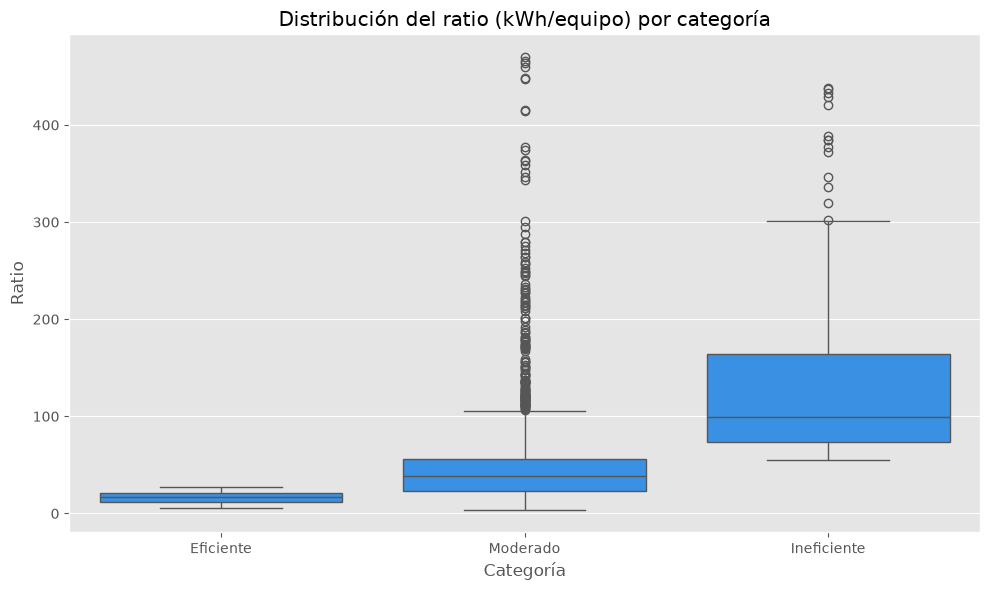

In [18]:
# Distribución del ratio por categoría
df['ratio'] = df['consumo_kwh'] / df['cantidad_equipos']

print("Distribución del ratio (consumo/equipos) por categoría:")
print("-" * 60)
print(df.groupby('categoria')['ratio'].describe())
print("\n")

# Boxplot del ratio por categoría
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='categoria', y='ratio', order=['Eficiente', 'Moderado', 'Ineficiente'], color='dodgerblue')
plt.title('Distribución del ratio (kWh/equipo) por categoría')
plt.ylabel('Ratio')
plt.xlabel('Categoría')
plt.tight_layout()
#plt.savefig(f'{OUTPUT_IMAGES_PATH}/ratio_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Conclusiones del EDA y definición de variables


Basado en el Análisis Exploratorio de Datos (EDA) realizado, se ha identificado el comportamiento de las variables iniciales y su relación con la categoría objetivo. Este análisis nos permite tomar decisiones fundamentadas para la siguiente fase del proyecto: la creación de un dataset enriquecido que mejore el rendimiento del modelo predictivo.

A continuación, se definen formalmente las variables que componen el dataset actual, se justifica la creación de nuevas variables y se establece la estrategia a seguir.

#### 5.1. Variables del Dataset Inicial

El dataset inicial (`dataset_inicial.csv`) contiene las siguientes variables, las cuales han sido validadas y analizadas en las secciones anteriores:

**A. Variables de Entrada (Inputs)**
Son los datos que el usuario proporcionaría a la API para obtener una predicción.

| Variable              | Tipo                  | Descripción                                               | Rango / Categorías    |
| ---                   | ---                   | ---                                                       | ---                   |
| `consumo_kwh`         | Numérica (Entero)     | Consumo eléctrico mensual en kilovatios-hora.             | 80 – 950 kWh          |
| `cantidad_equipos`    | Numérica (Entero)     | Número total de equipos/electrodomésticos en el inmueble. | 2 – 22 equipos        |
| `horas_alto_consumo`  | Numérica (Entero)     | Horas diarias promedio de mayor demanda energética.       | 2 – 14 horas          |
| `tipo_inmueble`       | Categórica (Nominal)  | Tipo de propiedad donde se mide el consumo.               | 'Casa', 'Apartamento', 'Local', 'Oficina' |
| `uso_horario_pico`    | Categórica (Binaria)  | Indica si el consumo se concentra en horarios pico (True/False). | True / False |

**B. Variables Derivadas (Calculadas)**
No son proporcionadas directamente por el usuario, sino que se calculan a partir de las variables de entrada para facilitar el análisis o alimentar el modelo.

| Variable  | Tipo                  | Descripción                               | Fórmula   |
| ---       | ---                   | ---                                       | ---       |
| `ratio`   | Numérica (Flotante)   | Indicador de eficiencia energética bruta. | `consumo_kwh / cantidad_equipos` |

**C. Variable de Salida (Target)**
Es la etiqueta que el modelo debe predecir.

| Variable      | Tipo                  | Descripción                                   | Categorías    |
| ---           | ---                   | ---                                           | ---           |
| `categoria`   | Categórica (Nominal)  | Perfil de eficiencia energética del inmueble. | 'Eficiente', 'Moderado', 'Ineficiente' |

#### 5.2. Variables del Dataset Extendido

El dataset extendido (`dataset_extendido.csv`) incorpora nuevas variables contextuales que enriquecen el análisis y mejoran la capacidad predictiva del modelo. A continuación, se detallan todas las variables que lo componen, validadas y analizadas en las secciones anteriores.

**A. Variables de Entrada (Inputs)**
Son los datos que el usuario proporcionaría a la API para obtener una predicción. Estas variables representan las características del inmueble y los hábitos de consumo.

| Variable | Tipo | Descripción | Rango / Categorías |
| :--- | :--- | :--- | :--- |
| `consumo_kwh` | Numérica (Entero) | Consumo eléctrico mensual en kilovatios-hora. | 80 – 1500 kWh |
| `cantidad_equipos` | Numérica (Entero) | Número total de equipos/electrodomésticos en el inmueble. | 2 – 25 equipos |
| `horas_alto_consumo` | Numérica (Entero) | Horas diarias promedio de mayor demanda energética. | 2 – 16 horas |
| `tipo_inmueble` | Categórica (Nominal) | Tipo de propiedad donde se mide el consumo. | 'Casa', 'Apartamento', 'Local', 'Oficina' |
| `uso_horario_pico` | Categórica (Binaria) | Indica si el consumo se concentra en horarios pico (True/False). | True / False |
| `numero_habitantes` | Numérica (Entero) | Número de personas que habitan el inmueble. | 1 – 6 personas |
| `antiguedad_inmueble` | Numérica (Entero) | Años de antigüedad de la construcción. | 0 – 50 años |
| `calefaccion` | Categórica (Binaria) | Indica si el inmueble cuenta con calefacción eléctrica. | True / False |
| `aire_acondicionado` | Categórica (Binaria) | Indica si el inmueble cuenta con aire acondicionado. | True / False |


**B. Variables Derivadas (Calculadas)**
No son proporcionadas directamente por el usuario, sino que se calculan internamente para la clasificación y el análisis.

| Variable | Tipo | Descripción | Fórmula |
| :--- | :--- | :--- | :--- |
| `ratio` | Numérica (Flotante) | Indicador de eficiencia energética bruta. Se usa como base para la clasificación. | `consumo_kwh / cantidad_equipos` |

*Nota:* La variable `ratio` es calculada durante la generación del dataset, pero **no se incluye en el archivo CSV final** para que el modelo aprenda a clasificar exclusivamente a partir de las variables de entrada reales (evitamos fugas de datos).


**C. Variable de Salida (Target)**
Es la etiqueta que el modelo debe predecir.

| Variable | Tipo | Descripción | Categorías |
| :--- | :--- | :--- | :--- |
| `categoria` | Categórica (Nominal) | Perfil de eficiencia energética del inmueble. | 'Eficiente', 'Moderado', 'Ineficiente' |


**D. Diferencias clave con el dataset inicial**

1. **Rangos ampliados:** Se ajustaron los límites de `consumo_kwh`, `cantidad_equipos` y `horas_alto_consumo` para reflejar una casuística más amplia y realista.
2. **Nuevas variables contextuales:** Se agregaron `numero_habitantes`, `antiguedad_inmueble`, `calefaccion` y `aire_acondicionado` para capturar factores de eficiencia que no dependen únicamente del consumo bruto.
3. **Lógica de clasificación mejorada:** La presencia de calefacción o aire acondicionado penaliza la clasificación (eleva el umbral de `ratio` para ser considerado eficiente), haciendo el modelo más justo y representativo.

In [19]:
# Crear el nuevo dataset
import sys

sys.path.append('..')
from scripts.generador_datos import generar_dataset_extendido

df_ext = generar_dataset_extendido(n=3000, seed=42)
print(f"Dataset extendido generado con {len(df_ext)} registros.\n")
df_ext.info()

Dataset extendido generado con 3000 registros.

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   consumo_kwh          3000 non-null   int64
 1   cantidad_equipos     3000 non-null   int32
 2   horas_alto_consumo   3000 non-null   int32
 3   tipo_inmueble        3000 non-null   str  
 4   uso_horario_pico     3000 non-null   bool 
 5   numero_habitantes    3000 non-null   int32
 6   antiguedad_inmueble  3000 non-null   int32
 7   calefaccion          3000 non-null   bool 
 8   aire_acondicionado   3000 non-null   bool 
 9   categoria            3000 non-null   str  
dtypes: bool(3), int32(4), int64(1), str(2)
memory usage: 126.1 KB
